In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, auc
)

np.random.seed(1210)

In [29]:
# Generate imbalanced toy dataset + 70%:30% split
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.90, 0.10],
    n_informative=5,
    n_redundant=2,
    n_repeated=0,
    n_clusters_per_class=2,
    flip_y=0.01,
    class_sep=1.0,
    random_state=1210
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=1210,
    stratify=y
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train class ratio (mean y):", y_train.mean(), " Test class ratio (mean y):", y_test.mean())

Train size: 700  Test size: 300
Train class ratio (mean y): 0.10428571428571429  Test class ratio (mean y): 0.10333333333333333


In [30]:
#Logistic Regression Model with four metrics
clf = LogisticRegression() 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 score:  {f1:.4f}")

Accuracy:  0.9833
Precision: 0.9643
Recall:    0.8710
F1 score:  0.9153


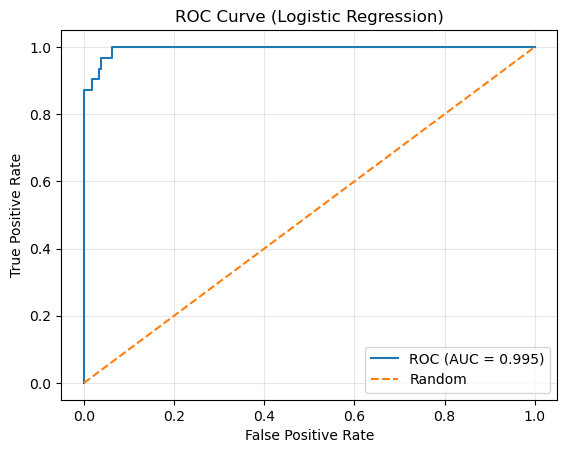

In [31]:
# ROC curve (use predicted probabilities)
y_score = clf.predict_proba(X_test)[:, 1]  # P(y=1)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

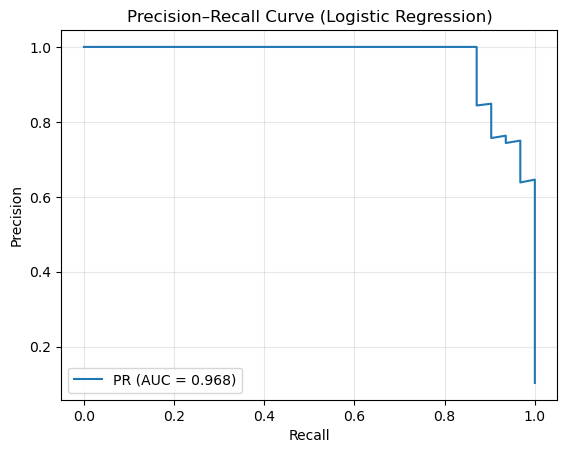

In [32]:
# Precision-Recall curve (use predicted probabilities)
precision, recall, _ = precision_recall_curve(y_test, y_score)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Logistic Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [111]:
def evaluate_at_threshold(y_true, y_score, thr, name="Model"):
    y_pred = (y_score >= thr).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{name} (threshold = {thr:.2f})")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")

    return {
        "threshold": thr,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

In [112]:
def point_at_threshold(y_true, y_score, thr):
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # ROC
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0 

    # PR
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)

    return fpr, tpr, rec, prec

In [96]:
def roc_point_at_threshold(y_true, y_score, thr):
    # Compute ONE ROC point from the chosen threshold
    y_pred = (y_score >= thr).astype(int)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return fpr, tpr

In [113]:
# Train new model; cost-sensitive training (balanced LR)
clf_bal = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=1210)
clf_bal.fit(X_train, y_train)
y_score_bal = clf_bal.predict_proba(X_test)[:, 1]
# Baseline at threshold 0.50
m_050 = evaluate_at_threshold(y_test, y_score_bal, 0.50, name="Balanced LR")


Balanced LR (threshold = 0.50)
Accuracy : 0.9267
Precision: 0.5882
Recall   : 0.9677
F1       : 0.7317


In [114]:
# Tune threshold to increase precision while keeping recall similar for the new model
thr = 0.60  # chosen manually
y_pred_manual = (y_score_bal >= thr).astype(int)

print("Precision:", precision_score(y_test, y_pred_manual))
print("Recall:", recall_score(y_test, y_pred_manual))

Precision: 0.7142857142857143
Recall: 0.967741935483871


In [115]:
thr = 0.65  # chosen manually
y_pred_manual = (y_score_bal >= thr).astype(int)

print("Precision:", precision_score(y_test, y_pred_manual))
print("Recall:", recall_score(y_test, y_pred_manual))

Precision: 0.7777777777777778
Recall: 0.9032258064516129


In [116]:
thr = 0.69  # chosen manually
y_pred_manual = (y_score_bal >= thr).astype(int)

print("Precision:", precision_score(y_test, y_pred_manual))
print("Recall:", recall_score(y_test, y_pred_manual))

Precision: 0.8235294117647058
Recall: 0.9032258064516129


In [117]:
thr = 0.70  # chosen manually
y_pred_manual = (y_score_bal >= thr).astype(int)

print("Precision:", precision_score(y_test, y_pred_manual))
print("Recall:", recall_score(y_test, y_pred_manual))

Precision: 0.84375
Recall: 0.8709677419354839


In [118]:
y_pred_069 = (y_score_bal >= thr).astype(int)
print("Accuracy :", accuracy_score(y_test, y_pred_069))
print("Precision:", precision_score(y_test, y_pred_069, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_069, zero_division=0))
print("F1       :", f1_score(y_test, y_pred_069, zero_division=0))

Accuracy : 0.97
Precision: 0.84375
Recall   : 0.8709677419354839
F1       : 0.8571428571428571


In [120]:
def plot_roc_with_markers(y_true, y_score, thresholds=(0.5, 0.69), title="ROC Curve"):
    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr_curve, tpr_curve)

    plt.figure()
    plt.plot(fpr_curve, tpr_curve, label=f"ROC (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", label="Random")

    for thr in thresholds:
        fpr_pt, tpr_pt, _, _ = point_at_threshold(y_true, y_score, thr)
        plt.scatter(fpr_pt, tpr_pt, s=80, label=f"thr={thr:.2f}")
        plt.annotate(
            f"{thr:.2f}",
            (fpr_pt, tpr_pt),
            textcoords="offset points",
            xytext=(6, -6)
        )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [121]:
def plot_pr_with_markers(y_true, y_score, thresholds=(0.5, 0.69), title="Precision–Recall Curve"):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall_curve, precision_curve)

    plt.figure()
    plt.plot(recall_curve, precision_curve, label=f"PR (AUC = {pr_auc:.3f})")

    for thr in thresholds:
        _, _, rec_pt, prec_pt = point_at_threshold(y_true, y_score, thr)
        plt.scatter(rec_pt, prec_pt, s=90, label=f"thr={thr:.2f}")
        plt.annotate(
            f"{thr:.2f}",
            (rec_pt, prec_pt),
            textcoords="offset points",
            xytext=(6, -6)
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [122]:
evaluate_at_threshold(y_test, y_score_bal, 0.50, name="Balanced LR")
evaluate_at_threshold(y_test, y_score_bal, 0.69, name="Balanced LR (tuned)")


Balanced LR (threshold = 0.50)
Accuracy : 0.9267
Precision: 0.5882
Recall   : 0.9677
F1       : 0.7317

Balanced LR (tuned) (threshold = 0.69)
Accuracy : 0.9700
Precision: 0.8235
Recall   : 0.9032
F1       : 0.8615


{'threshold': 0.69,
 'accuracy': 0.97,
 'precision': 0.8235294117647058,
 'recall': 0.9032258064516129,
 'f1': 0.8615384615384616}

In [125]:
from sklearn.metrics import confusion_matrix

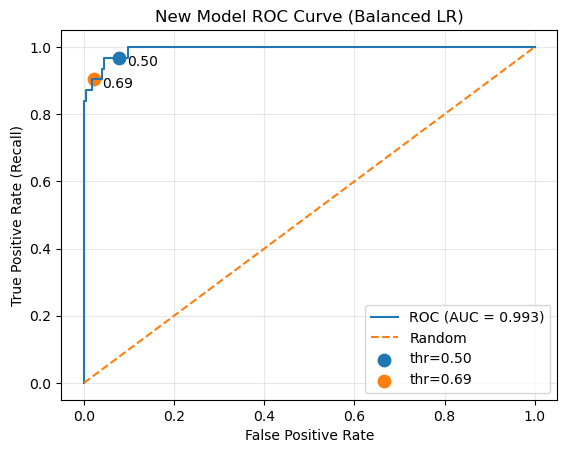

In [126]:
plot_roc_with_markers(
    y_test, y_score_bal,
    thresholds=(0.50, 0.69),
    title="New Model ROC Curve (Balanced LR)"
)

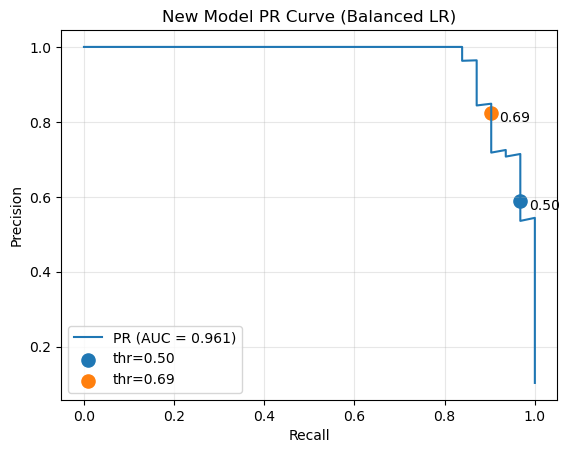

In [128]:
plot_pr_with_markers(
    y_test, y_score_bal,
    thresholds=(0.50, 0.69),
    title="New Model PR Curve (Balanced LR)"
)